# 🏙️ Airbnb New York City — Data Cleaning and Analysis

Welcome to New York City — one of the most-visited cities in the world.  
With thousands of Airbnb listings available across its boroughs, understanding the rental market can reveal valuable insights about pricing, locations, and host behavior.

In this project, we’ll explore **Airbnb listing data from 2019**, collected from multiple file formats: `.csv`, `.xlsx`, and `.tsv`.  
We’ll combine, clean, and analyze the data to uncover trends in prices, room types, and host activity.

### 📂 Datasets Overview
We’ll work with three files containing information on listings, hosts, and reviews:

#### **1. `airbnb_price.csv`**
Contains data on listing prices and locations.
- `listing_id`: Unique listing identifier  
- `price`: Nightly price in USD  
- `nbhood_full`: Borough and neighborhood name

#### **2. `airbnb_room_type.xlsx`**
Contains data on listing descriptions and room types.
- `listing_id`: Unique listing identifier  
- `description`: Text description of the property  
- `room_type`: Airbnb room category — shared room, private room, or entire home/apartment

#### **3. `airbnb_last_review.tsv`**
Contains data on host names and the date of the last review.
- `listing_id`: Unique listing identifier  
- `host_name`: Name of the host  
- `last_review`: Date of the most recent review

### 🎯 Project Objective
To analyze Airbnb listings in New York City to understand **price patterns**, **popular room types**, and **host activity**, while demonstrating skills in:
- Loading and merging multiple data formats  
- Validating and cleaning data  
- Conducting exploratory data analysis (EDA)  
- Visualizing and interpreting insights

## **1. Import Libraries and Load Dataset**

We’ll start by importing the necessary Python libraries and loading all three datasets.  
Each file format will be read using the appropriate `pandas` method:  
- `.csv` → `read_csv()`  
- `.xlsx` → `read_excel()`  
- `.tsv` → `read_csv(sep='\t')`

In [ ]:
# Import necessary packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

price = pd.read_csv("dataset/data_airbnb/airbnb_price.csv")

room_type = pd.read_excel("dataset/data_airbnb/airbnb_room_type.xlsx")

last_review = pd.read_csv("dataset/data_airbnb/airbnb_last_review.tsv", sep="\t")


### **Preview each dataset**

Before diving deeper, let’s look at the first few rows of each dataset to confirm that the data has loaded correctly and to get an initial sense of the structure.


In [172]:
display(price.head(), room_type.head(10), last_review.head())

,listing_id,price,nbhood_full
0,2595,225 dollars,"Manhattan, Midtown"
1,3831,89 dollars,"Brooklyn, Clinton Hill"
2,5099,200 dollars,"Manhattan, Murray Hill"
3,5178,79 dollars,"Manhattan, Hell's Kitchen"
4,5238,150 dollars,"Manhattan, Chinatown"


,listing_id,description,room_type
0,2595,Skylit Midtown Castle,Entire home/apt
1,3831,Cozy Entire Floor of Brownstone,Entire home/apt
2,5099,Large Cozy 1 BR Apartment In Midtown East,Entire home/apt
3,5178,Large Furnished Room Near B'way,private room
4,5238,Cute & Cozy Lower East Side 1 bdrm,Entire home/apt
5,5295,Beautiful 1br on Upper West Side,Entire home/apt
6,5441,Central Manhattan/near Broadway,Private room
7,5803,"Lovely Room 1, Garden, Best Area, Legal rental",Private room
8,6021,Wonderful Guest Bedroom in Manhattan for SINGLES,Private room
9,6848,Only 2 stops to Manhattan studio,entire home/apt


,listing_id,host_name,last_review
0,2595,Jennifer,May 21 2019
1,3831,LisaRoxanne,July 05 2019
2,5099,Chris,June 22 2019
3,5178,Shunichi,June 24 2019
4,5238,Ben,June 09 2019


## **2. Explore the structure of each dataset & Data Validation:**
This helps confirm:
- Number of rows and columns
- Data types (e.g., object, float64, datetime64)
- Whether there are missing values

In [137]:
print(price.info(), "\n")
print(room_type.info(), "\n")
print(last_review.info(), "\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   price        25209 non-null  object
 2   nbhood_full  25209 non-null  object
dtypes: int64(1), object(2)
memory usage: 591.0+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   description  25199 non-null  object
 2   room_type    25209 non-null  object
dtypes: int64(1), object(2)
memory usage: 591.0+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   host_name    25201 n

Analyse the result:
From the summary output:
- Each dataset contains **25,209 rows** and **3 columns**.
- The `price` column is stored as **text** (e.g., `"225 dollars"`) and will need to be converted to numeric format.
- The `room_type` column has **inconsistent capitalization** (e.g., `"Private Room"` vs `"private room"`).
- Some missing values:
  - `description`: 10 missing entries (25,199 non-null)
  - `host_name`: 8 missing entries (25,201 non-null)

Overall, the data is mostly clean, with only minor text-based missing values that won’t affect numerical analysis.

In [138]:
print("=== Missing Values Check ===")
print("Price Data:\n", price.isna().sum(), "\n")
print("Room Type Data:\n", room_type.isna().sum(), "\n")
print("Last Review Data:\n", last_review.isna().sum(), "\n")

=== Missing Values Check ===
Price Data:
 listing_id     0
price          0
nbhood_full    0
dtype: int64 

Room Type Data:
 listing_id      0
description    10
room_type       0
dtype: int64 

Last Review Data:
 listing_id     0
host_name      8
last_review    0
dtype: int64 



Meaning:
- No missing values in airbnb_price → clean dataset.
- In airbnb_room_type:
    - 10 missing description values → some listings don’t have text descriptions.
- In airbnb_last_review:
    - 8 missing host_name values → a few listings don’t have host names.
So, your data is almost perfectly clean — only minor missing text fields.

Fill the missing values:
- It won’t cause errors or major impact on your main analysis because the missing field is just the text, not the number.
- We may see some “NaN” values if you print or export.
- We can tidy up the dataset to make it look cleaner when exporting or visualizing.

In [139]:
# Replace missing descriptions and host names with "Unknown"
room_type['description'].fillna('No description available', inplace=True)
last_review['host_name'].fillna('Unknown', inplace=True)

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1479665941.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  room_type['description'].fillna('No description available', inplace=True)
C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1479665941.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [140]:
print("=== Duplicate ID Check ===")
print("Price duplicates:", price['listing_id'].duplicated().sum())
print("Room type duplicates:", room_type['listing_id'].duplicated().sum())
print("Last review duplicates:", last_review['listing_id'].duplicated().sum())

=== Duplicate ID Check ===
Price duplicates: 0
Room type duplicates: 0
Last review duplicates: 0


There are **no duplicate listing IDs** in any dataset.
It means every Airbnb listing appears only once in each dataset, so we can safely merge them later without worrying about duplicate rows.

In [141]:
print("=== ID Alignment Check ===")
ids_price = set(price['listing_id'])
ids_room = set(room_type['listing_id'])
ids_review = set(last_review['listing_id'])

print("IDs in all three datasets:", len(ids_price & ids_room & ids_review))
print("Only in price data:", len(ids_price - ids_room - ids_review))
print("Only in room type data:", len(ids_room - ids_price - ids_review))
print("Only in review data:", len(ids_review - ids_price - ids_room))

=== ID Alignment Check ===
IDs in all three datasets: 25209
Only in price data: 0
Only in room type data: 0
Only in review data: 0


Summary:

- The datasets are fully aligned — all contain **25,209 unique listing IDs**.  
- No duplicate IDs were found across any of the files.  
- Minor missing values exist only in non-critical text fields (`description`, `host_name`).

✅ Overall, the datasets are consistent and ready to be cleaned and merged.

## **3. Merging the three DataFrames**

In [142]:
# Merge price and room type data
airbnb_merged = pd.merge(price, room_type, on='listing_id')

# Merge the result with the last review data
airbnb_merged = pd.merge(airbnb_merged, last_review, on='listing_id')

# Take a look at the result
airbnb_merged.head()

,listing_id,price,nbhood_full,description,room_type,host_name,last_review
0,2595,225 dollars,"Manhattan, Midtown",Skylit Midtown Castle,Entire home/apt,Jennifer,May 21 2019
1,3831,89 dollars,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,Entire home/apt,LisaRoxanne,July 05 2019
2,5099,200 dollars,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,Entire home/apt,Chris,June 22 2019
3,5178,79 dollars,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room,Shunichi,June 24 2019
4,5238,150 dollars,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,Entire home/apt,Ben,June 09 2019


##  4. Data Cleaning

Now that we’ve validated the structure, we can clean the data for analysis.

### Steps to Clean:
1. **Convert last_review** from string to datetime type
2. **Standardize text fields** — ensure consistent formatting in columns like `room_type`.  
3. **Convert prices** from strings (e.g., `"$225"`) to numeric values.  



1. Convert `last_review` from string to datetime type

In [143]:
# Convert the 'last_review' column to datetime
airbnb_merged["last_review"] = pd.to_datetime(airbnb_merged["last_review"])

# Take a look at the result
airbnb_merged.head()

,listing_id,price,nbhood_full,description,room_type,host_name,last_review
0,2595,225 dollars,"Manhattan, Midtown",Skylit Midtown Castle,Entire home/apt,Jennifer,2019-05-21
1,3831,89 dollars,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,Entire home/apt,LisaRoxanne,2019-07-05
2,5099,200 dollars,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,Entire home/apt,Chris,2019-06-22
3,5178,79 dollars,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room,Shunichi,2019-06-24
4,5238,150 dollars,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,Entire home/apt,Ben,2019-06-09


2. Standardized `room_type` column
- `str.lower()` → converts all text to lowercase ("Private Room" → "private room").
- `str.strip()` → removes any leading or trailing spaces (in case of data entry errors).

In [144]:
# Clean capitalization in the room_type column
airbnb_merged['room_type'] = airbnb_merged['room_type'].str.lower().str.strip()

3. Clean `price` column

`replace('[\ dollars]', '', regex=True)`
→ Removes any 'dollars' string in price strings using a regular expression.
Example: "225 dollars" → "225"

`astype(float)`
→ Converts cleaned strings to numeric floats, allowing math operations.

`mean()`
→ Computes the average value of all numeric entries in the price column.

In [145]:
# Clean the 'price' column by removing '$' and ',' and convert it to float
airbnb_merged['price'] = (
    airbnb_merged['price']
    .replace('[\ dollars]', '', regex=True)   # remove $ and ,
    .astype(float)                      # convert to float
)

airbnb_merged.head(10)

,listing_id,price,nbhood_full,description,room_type,host_name,last_review
0,2595,225.0,"Manhattan, Midtown",Skylit Midtown Castle,entire home/apt,Jennifer,2019-05-21
1,3831,89.0,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,entire home/apt,LisaRoxanne,2019-07-05
2,5099,200.0,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,entire home/apt,Chris,2019-06-22
3,5178,79.0,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room,Shunichi,2019-06-24
4,5238,150.0,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,entire home/apt,Ben,2019-06-09
5,5295,135.0,"Manhattan, Upper West Side",Beautiful 1br on Upper West Side,entire home/apt,Lena,2019-06-22
6,5441,85.0,"Manhattan, Hell's Kitchen",Central Manhattan/near Broadway,private room,Kate,2019-06-23
7,5803,89.0,"Brooklyn, South Slope","Lovely Room 1, Garden, Best Area, Legal rental",private room,Laurie,2019-06-24
8,6021,85.0,"Manhattan, Upper West Side",Wonderful Guest Bedroom in Manhattan for SINGLES,private room,Claudio,2019-07-05
9,6848,140.0,"Brooklyn, Williamsburg",Only 2 stops to Manhattan studio,entire home/apt,Allen & Irina,2019-06-29


In [146]:
airbnb_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   listing_id   25209 non-null  int64         
 1   price        25209 non-null  float64       
 2   nbhood_full  25209 non-null  object        
 3   description  25209 non-null  object        
 4   room_type    25209 non-null  object        
 5   host_name    25209 non-null  object        
 6   last_review  25209 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 1.3+ MB


In [147]:
# Calculate the average price of all listings
avg_price = airbnb_merged['price'].mean()

print("Average listing price (USD):", avg_price)

Average listing price (USD): 141.7779364512674


## **5. Quick Look at Price Distributions**

Before starting any data analyse, let's visualize the raw price distribution and observe the price.
To identify how realistic of the prices, because the dataset may contain some error or distorting.

Text(0.5, 1.0, 'Price Histogram')

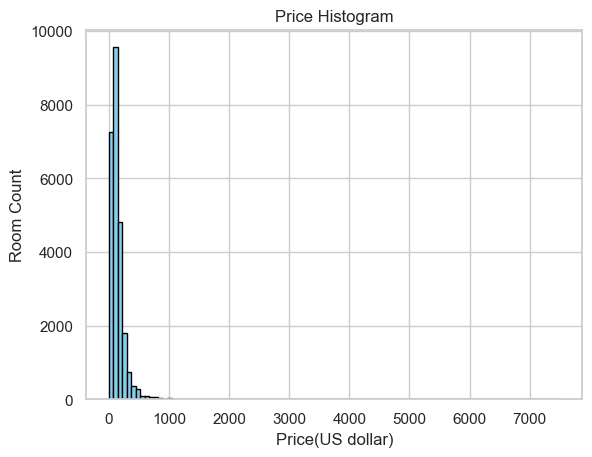

In [148]:
# Plotting a basic histogram
plt.hist(airbnb_merged['price'], bins=100, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Price(US dollar)')
plt.ylabel('Room Count')
plt.title('Price Histogram')

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\3332927894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=airbnb_merged, x='room_type', y='price', palette='Set2')


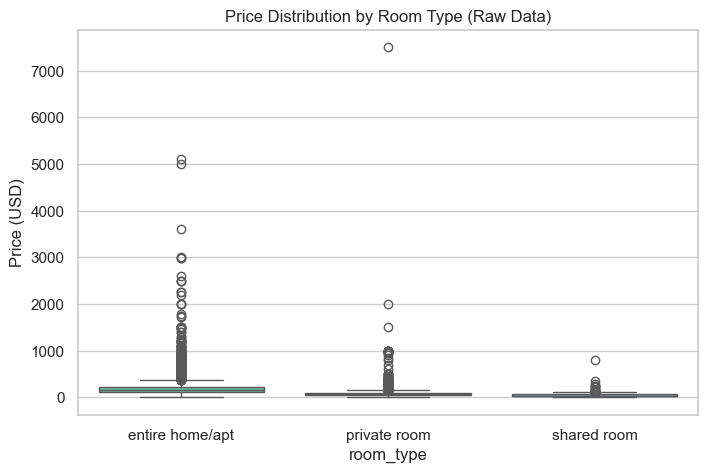

In [149]:
plt.figure(figsize=(8,5))
sns.boxplot(data=airbnb_merged, x='room_type', y='price', palette='Set2')
plt.title("Price Distribution by Room Type (Raw Data)")
plt.ylabel("Price (USD)")
plt.show()

In [150]:
# Find 10 lowest price
airbnb_merged[['price', 'nbhood_full', 'room_type']].sort_values('price', ascending=True).head(10)

,price,nbhood_full,room_type
10861,0.0,"Bronx, East Morrisania",private room
10958,0.0,"Brooklyn, Bushwick",private room
11577,0.0,"Brooklyn, Bushwick",shared room
11589,0.0,"Brooklyn, Bushwick",shared room
11024,0.0,"Brooklyn, Bedford-Stuyvesant",private room
11025,0.0,"Brooklyn, Bedford-Stuyvesant",private room
11023,0.0,"Brooklyn, Bedford-Stuyvesant",private room
24806,10.0,"Brooklyn, Bushwick",private room
16643,10.0,"Brooklyn, Bedford-Stuyvesant",entire home/apt
12135,10.0,"Brooklyn, Greenpoint",entire home/apt


In [151]:
# Find 10 highest price
airbnb_merged[['price', 'nbhood_full', 'room_type']].sort_values('price', ascending=False).head(10)

,price,nbhood_full,room_type
23916,7500.0,"Brooklyn, East Flatbush",private room
22085,5100.0,"Manhattan, Midtown",entire home/apt
18430,5000.0,"Manhattan, Harlem",entire home/apt
21731,3613.0,"Manhattan, Upper West Side",entire home/apt
12508,3000.0,"Manhattan, SoHo",entire home/apt
24432,2995.0,"Manhattan, Chelsea",entire home/apt
13528,2990.0,"Manhattan, Nolita",entire home/apt
21838,2600.0,"Queens, Bayside",entire home/apt
1234,2500.0,"Manhattan, East Village",entire home/apt
23601,2500.0,"Brooklyn, Crown Heights",entire home/apt


Observation:
- The price isn't reasonable, since there are some room which cost only 0 US dollar per night which there are some room where the price up to 7500 US dollar.
- These prices can be errors or outliers in this dataset, can come from missing data (for 0$ room) or typos (for 7500$)
- These outliers distort averages and make visualizations misleading

## 6. Outlier Detection and Cleaning
Some listings had unrealistic prices (e.g., $0 or over $7000), which could distort analysis.  
To fix this, I used the **Interquartile Range (IQR)** method to detect and remove outliers.

 What is the IQR Method?

The **Interquartile Range (IQR)** measures the spread of the middle 50% of the data.  
It is calculated as:

IQR = Q3 - Q1

Where:
- **Q1** = 25th percentile (lower quartile)  
- **Q3** = 75th percentile (upper quartile)

Any value below **Q1 − 3×IQR** or above **Q3 + 3×IQR** is considered an outlier.

Since Airbnb prices vary greatly by room type (e.g., entire homes are more expensive than private rooms),  
we apply the IQR method **within each room type** to avoid unfairly removing valid high-end listings.


### Applying IQR per Room Type

We define a function to compute the IQR for each `room_type` group and remove values outside the acceptable range.  
This ensures that price filtering respects the natural variation between room types.


In [178]:
def remove_outliers_iqr(group, k=3):
    Q1, Q3 = group['price'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - k*IQR, Q3 + k*IQR
    return group[(group['price'] >= lower) & (group['price'] <= upper)]

airbnb_clean = airbnb_merged.groupby('room_type', group_keys=False).apply(remove_outliers_iqr, k=3)

print(f"Original rows: {len(airbnb_merged)}, After cleaning: {len(airbnb_clean)}")

Original rows: 25209, After cleaning: 24636


C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\2852472270.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  airbnb_clean = airbnb_merged.groupby('room_type', group_keys=False).apply(remove_outliers_iqr, k=3)


Compare before and after:

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1781390573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=airbnb_merged, x='room_type', y='price', ax=axes[0], palette='Set2')
C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1781390573.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=airbnb_clean, x='room_type', y='price', ax=axes[1], palette='Set2')


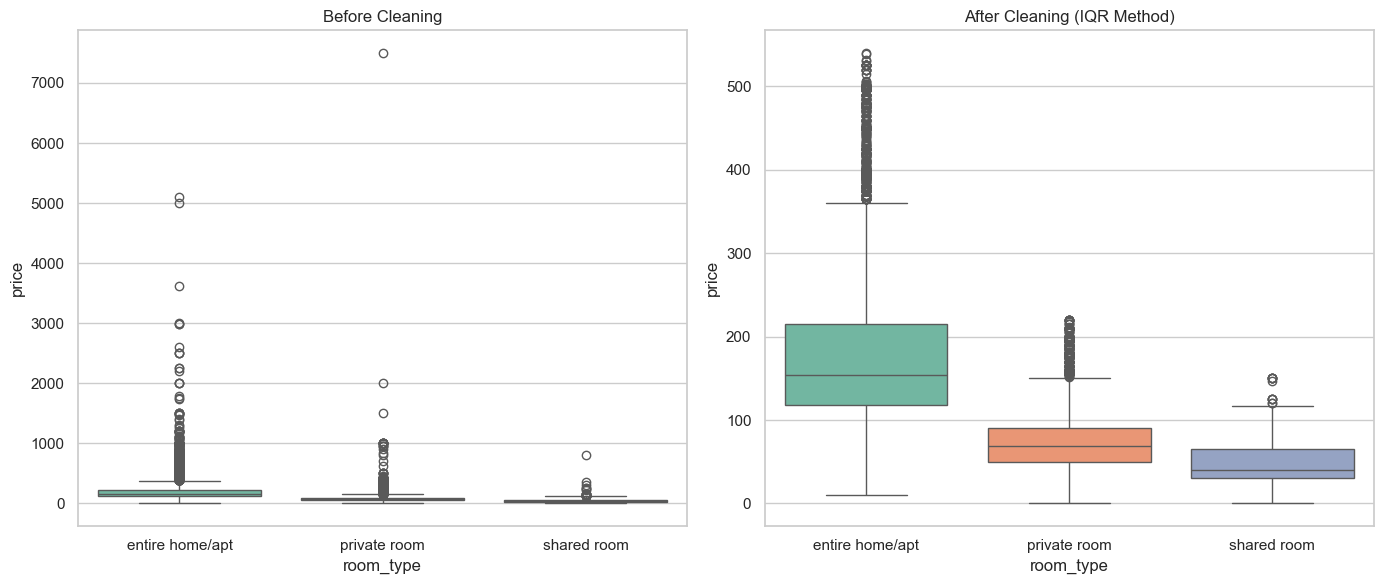

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.boxplot(data=airbnb_merged, x='room_type', y='price', ax=axes[0], palette='Set2')
axes[0].set_title("Before Cleaning")
sns.boxplot(data=airbnb_clean, x='room_type', y='price', ax=axes[1], palette='Set2')
axes[1].set_title("After Cleaning (IQR Method)")
plt.tight_layout()
plt.show()

### Price Distribution Before vs After Cleaning Result

Each boxplot shows the **distribution of Airbnb prices** for each room type (`entire home/apt`, `private room`, and `shared room`).

- **The box** represents the middle 50% of listings — prices between the 25th and 75th percentile.  
- **The line inside the box** is the **median price**, showing the midpoint of all listings.  
- **The whiskers** :
  - The lines extending from the box show the range of “normal” data — typically within 1.5 × IQR from Q1 and Q3.
  - Any value that lies outside that whisker range is considered an outlier.
- **Dots (●)** beyond the whiskers are **outliers** — unusually high or low prices compared to most listings.

#### From the chart:
- In the **Before Cleaning** plot (left), there are many outlier dots far above the main boxes, with prices reaching up to **\$7000+** per night.  
  These extreme values stretch the scale and make it difficult to see the normal price range.  
- In the **After Cleaning (IQR Method)** plot (right), the outliers are fewer and closer to the main box.  
  Now, the typical nightly prices are much clearer:
  - **Entire homes/apts:** around **\$150–\$200**
  - **Private rooms:** around **\$60–\$90**
  - **Shared rooms:** around **\$30–\$60**

This visualization shows how cleaning the data using the **IQR method** helps highlight realistic market prices while preserving natural variation.

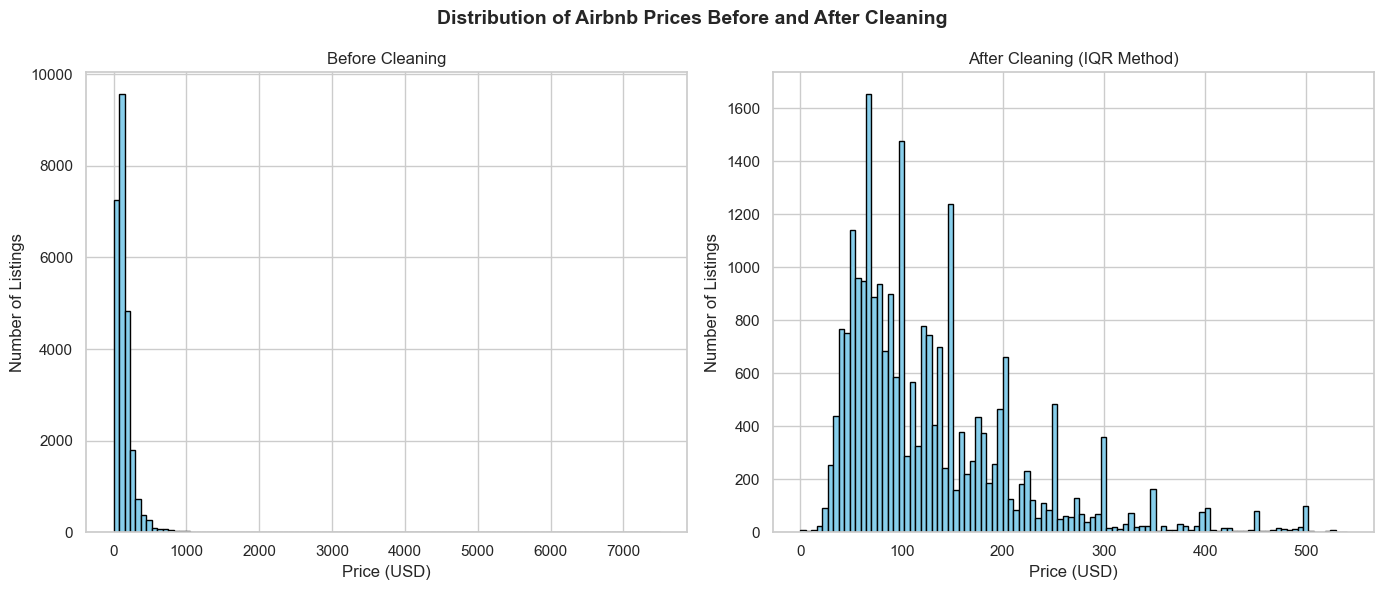

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram before cleaning
axes[0].hist(airbnb_merged['price'], bins=100, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Number of Listings")

# Histogram after cleaning
axes[1].hist(airbnb_clean['price'], bins=100, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning (IQR Method)")
axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("Number of Listings")

plt.suptitle("Distribution of Airbnb Prices Before and After Cleaning", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpreting the Histograms

- **Before Cleaning:**:
  - The x-axis extends all the way up to $7000+, but most listings are actually below $500.
  - Those extremely high prices stretch the x-axis, so all the real data are squished into the first few bins.
  - The result: almost all bars are crowded near zero, and the rest of the plot looks “empty.”

- **After Cleaning:**:
  - After removing outliers, the scale becomes realistic (most listings under $500).
  - You can now see a true distribution shape — roughly right-skewed but much smoother and interpretable.
  - This histogram reveals that most Airbnb listings fall between $50–$200, with a gradual decline toward higher prices.

## 7. Univariate Analysis
Now that the dataset has been cleaned, we can safely explore single-variable (univariate) trends to understand the overall structure of the Airbnb market in NYC.

1. Review dates
2. Room type distribution
3. Average Price
4. Top 10 host that has highest number of property listed

### Earliest and Latest Review Dates

Checking the earliest and most recent reviews helps confirm the time coverage of our dataset.  
This gives context to how recent or active the listings were when data was collected.

In [155]:
# 1. Review dates
airbnb_clean['last_review'] = pd.to_datetime(airbnb_clean['last_review'], errors='coerce')
print("Earliest review:", airbnb_clean['last_review'].min().date())
print("Latest review:", airbnb_clean['last_review'].max().date())

Earliest review: 2019-01-01
Latest review: 2019-07-09


### Room Type Distribution

Next, we’ll look at how listings are distributed across different room types (entire homes, private rooms, and shared rooms).  
This helps identify what kind of spaces dominate the New York Airbnb market.

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\3922401942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=room_counts.index, y=room_counts.values, palette='pastel')


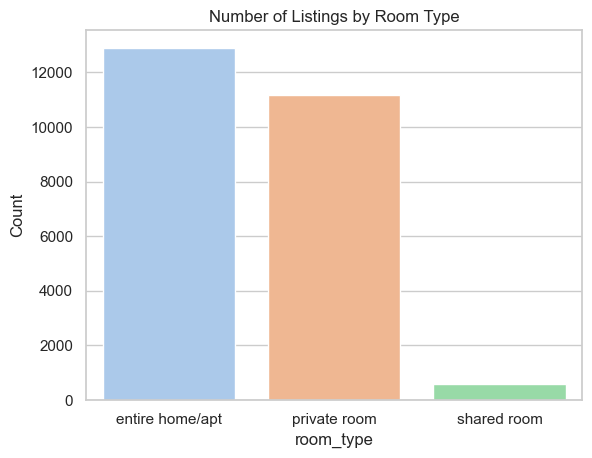

In [156]:
# 2. Room type distribution
room_counts = airbnb_clean['room_type'].value_counts()
sns.barplot(x=room_counts.index, y=room_counts.values, palette='pastel')
plt.title("Number of Listings by Room Type")
plt.ylabel("Count")
plt.show()


### Distribution of Room Types in New York City

This bar chart shows the number of Airbnb listings by room type.

- **Entire homes/apartments** are the most common type of listing, indicating that many hosts rent out full properties rather than just individual rooms.  
  This trend may be driven by professional hosts or property investors who manage multiple full units.  
- **Private rooms** are the second most common, representing hosts who rent out a spare bedroom in their residence.  
- **Shared rooms** make up only a small portion of listings — likely due to lower privacy and demand in a city where visitors prefer more personal space.

**Key takeaway:**  
The New York Airbnb market is dominated by *entire home/apartment rentals*, showing a shift toward short-term investment-style hosting rather than casual home sharing.


In [157]:
# 3. Room type distribution
avg_price = airbnb_clean['price'].mean().round(2)
print(f'Averate price per night: {avg_price}')

Averate price per night: 128.84


C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\3016273388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='muted')


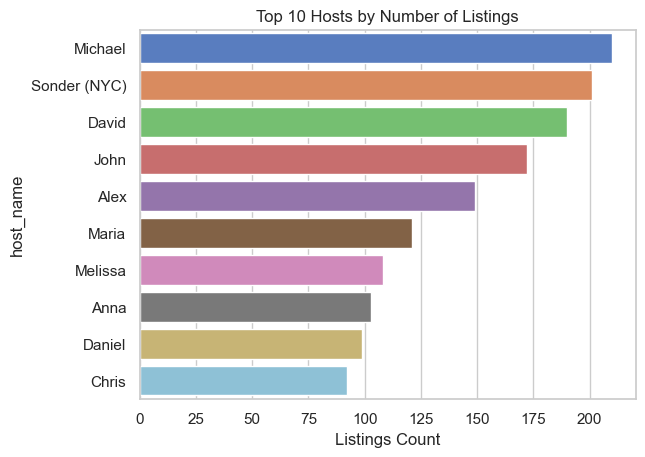

In [158]:
# 4. Most active hosts
top_hosts = airbnb_clean['host_name'].value_counts().head(10)
sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='muted')
plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Listings Count")
plt.show()


In [159]:
# 5. Top 10 neighborhoods by number of property listed
top_nbhood_full = airbnb_clean['nbhood_full'].value_counts().head(10)
print(top_nbhood_full)

nbhood_full
Brooklyn, Bedford-Stuyvesant    2196
Brooklyn, Williamsburg          1821
Manhattan, Harlem               1422
Brooklyn, Bushwick              1199
Manhattan, Hell's Kitchen       1080
Manhattan, East Village          844
Manhattan, Upper East Side       819
Manhattan, Upper West Side       744
Brooklyn, Crown Heights          744
Manhattan, East Harlem           664
Name: count, dtype: int64


## 8. Bivariate Analysis
The process of exploring the relationship between two variables in a dataset.  
While **univariate analysis** focuses on understanding each variable individually (like price distribution or number of listings),  
**bivariate analysis** helps uncover how one variable influences or relates to another — for example:

- How does **room type** affect **price**?  
- Which **boroughs or neighborhoods** have the highest average prices?  
- Are there patterns linking **location** and **room availability**?

By comparing two dimensions at a time, we can identify meaningful patterns and insights that help explain **what factors drive Airbnb pricing** in New York City.


In [160]:
# 1. Average price by room type
avg_price_by_type = airbnb_clean.groupby('room_type')['price'].mean().round(2)
print(avg_price_by_type)

room_type
entire home/apt    178.26
private room        75.83
shared room         49.97
Name: price, dtype: float64


In [161]:
# 2. Top 10 neighborhoods by average price
avg_price_by_nbhood = airbnb_clean.groupby('nbhood_full')['price'].mean().sort_values(ascending=False).head(5)
print(avg_price_by_nbhood)

nbhood_full
Manhattan, Tribeca              283.673469
Manhattan, NoHo                 281.342105
Queens, Neponsit                274.666667
Manhattan, Flatiron District    261.741935
Staten Island, Willowbrook      249.000000
Name: price, dtype: float64


Luxury neighborhoods such as **Tribeca, NoHo, and the Flatiron District** dominate the top spots, confirming Manhattan’s reputation as the city’s most premium short-term rental market. 

To better understand broader market trends, we can **aggregate neighborhoods by borough**.  
This approach helps us see the bigger picture — how average prices and listing counts differ across New York’s five main boroughs:  
**Manhattan, Brooklyn, Queens, Bronx, and Staten Island.**

In [162]:
# Extract borough (first part before the comma in nbhood_full)
airbnb_clean['borough'] = airbnb_clean['nbhood_full'].apply(lambda x: x.split(',')[0])
airbnb_clean['borough'].value_counts()

borough
Brooklyn         10339
Manhattan         9892
Queens            3442
Bronx              697
Staten Island      266
Name: count, dtype: int64

In [163]:
airbnb_clean.groupby('borough')['price'].mean().sort_values(ascending=False)

borough
Manhattan        161.452082
Brooklyn         114.876100
Queens            90.651365
Staten Island     85.484962
Bronx             78.279770
Name: price, dtype: float64

**Insight:**  
- **Manhattan** leads with the highest average price (\$161), driven by luxury properties and prime locations.  
- **Brooklyn** has the most listings, suggesting it’s a popular and more affordable alternative for travelers.  
- **Queens**, **Bronx**, and **Staten Island** offer the most budget-friendly options.

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1054275175.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=airbnb_clean, x='borough', y='price', hue='room_type', ci=None, palette='Set2')


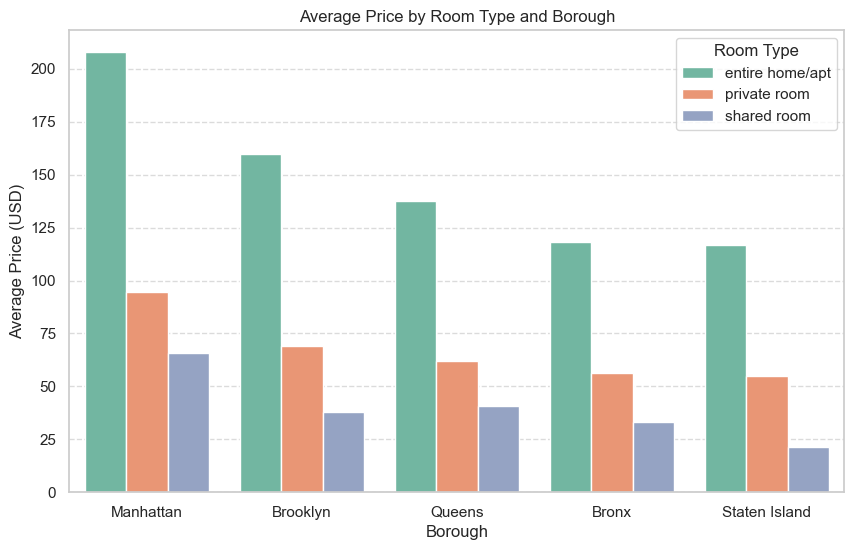

In [164]:
plt.figure(figsize=(10,6))
sns.barplot(data=airbnb_clean, x='borough', y='price', hue='room_type', ci=None, palette='Set2')
plt.title('Average Price by Room Type and Borough')
plt.ylabel('Average Price (USD)')
plt.xlabel('Borough')
plt.legend(title='Room Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Average Price by Room Type and Borough

To better understand how location and property type influence pricing,  
the chart above compares **average Airbnb prices** across New York’s five boroughs, split by **room type** (entire home/apartment, private room, shared room).

**Observations:**
1. **Entire homes/apartments show the widest price gap across boroughs.**  
   - Manhattan’s entire-home prices are nearly **double** those in Queens or the Bronx.  
   - This indicates that **location heavily influences premium property pricing**, as entire homes cater to higher-income travelers or larger groups.

2. **Private and shared rooms have relatively consistent prices across boroughs.**  
   - Except for Manhattan, where even private rooms are priced higher,  
     most other boroughs (Brooklyn, Queens, Bronx, Staten Island) cluster around similar price ranges.  
   - This suggests that **budget travelers or solo guests** have more flexibility in choosing location,  
     since price differences are minimal for these room types.

3. **Manhattan commands a premium across all room types.**  
   - Even shared rooms in Manhattan cost about the same as private rooms elsewhere.  
   - This highlights the **centralized demand** for accommodation near major attractions and business districts.

**In summary:**  
Room type is the main driver of price, but **location amplifies that effect** — especially for premium listings.  
For travelers, this means choosing a private or shared room gives pricing consistency city-wide,  
while for hosts, offering entire homes in high-demand boroughs like Manhattan or Brooklyn can yield the highest returns.

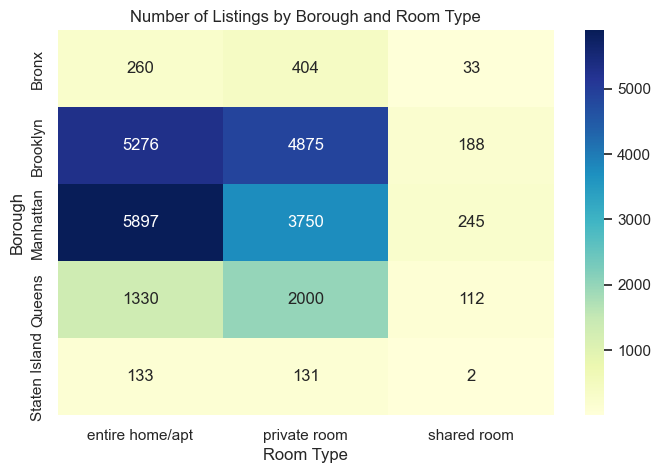

In [165]:
room_counts = pd.crosstab(airbnb_clean['borough'], airbnb_clean['room_type'])

plt.figure(figsize=(8,5))
sns.heatmap(room_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Number of Listings by Borough and Room Type')
plt.xlabel('Room Type')
plt.ylabel('Borough')
plt.show()

### Number of Listings by Borough and Room Type

The heatmap below visualizes the **number of Airbnb listings** for each room type within every borough.  
Darker shades represent higher listing counts.

**Key Takeaways:**
- **Brooklyn and Manhattan** dominate the Airbnb market, together accounting for the majority of listings.  
- Both boroughs have a balanced mix of **entire homes/apartments** and **private rooms**, showing strong supply in both premium and mid-range markets.  
- **Shared rooms** are relatively rare across all boroughs — they make up only a small fraction of total listings.  
- **Bronx**, and **Staten Island** have much smaller markets, serving niche or budget-conscious travelers.  

## Host Analysis

To explore which hosts dominate the New York Airbnb market, we analyzed **total earnings** (sum of listing prices) and the **distribution of their listings** across boroughs.

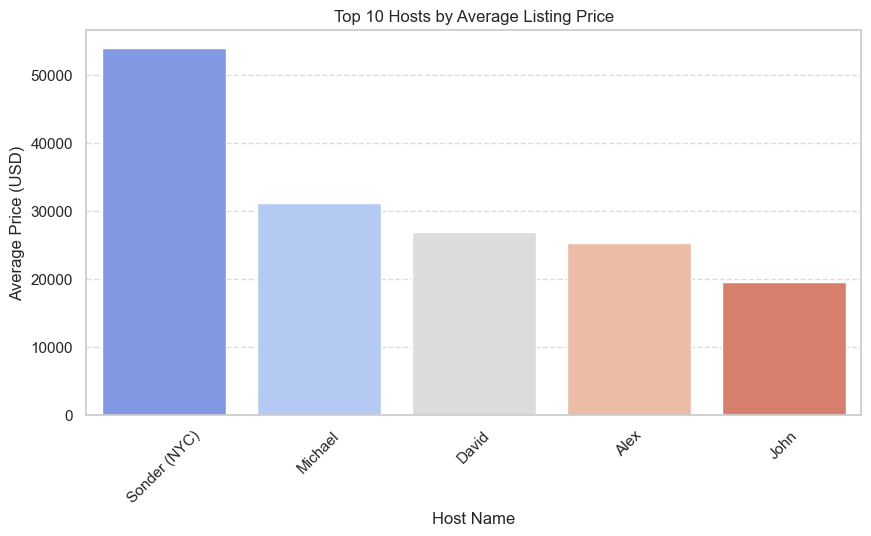

In [166]:
# Host Earning Estimation
top_host_prices = (
    airbnb_clean.groupby('host_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head()
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_host_prices.index,
    y=top_host_prices.values,
    hue=top_host_prices.index,
    palette='coolwarm',
    legend=False,
    errorbar=None
)
plt.title('Top 10 Hosts by Average Listing Price')
plt.ylabel('Average Price (USD)')
plt.xlabel('Host Name')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribution of Listings for Top 5 Hosts

To understand *where* these top hosts operate, we mapped the number of listings per borough.

In [167]:
top_hosts = top_host_prices.index

top_host_data = airbnb_clean[airbnb_clean['host_name'].isin(top_hosts)]

top_host_data

,listing_id,price,nbhood_full,description,room_type,host_name,last_review,borough
153,56525,195.0,"Brooklyn, Greenpoint",1 Bedroom Loft w/ Private Roof Deck,entire home/apt,Alex,2019-06-13,Brooklyn
252,85094,79.0,"Brooklyn, Crown Heights",Garden 1BR/1BA Brownstone Apt - 2 blocks to su...,entire home/apt,Alex,2019-01-14,Brooklyn
268,105510,100.0,"Brooklyn, Crown Heights",Private 1-Bedroom Apt in Townhouse,entire home/apt,Alex,2019-01-05,Brooklyn
428,233189,179.0,"Manhattan, Hell's Kitchen",NYC Studio in Heart of Times Square,entire home/apt,Michael,2019-05-31,Manhattan
682,433414,150.0,"Brooklyn, Clinton Hill",Spacious & Sunny in Prime Brooklyn,entire home/apt,David,2019-06-28,Brooklyn
...,...,...,...,...,...,...,...,...
24950,35804589,110.0,"Queens, Astoria",Heart of Astoria,shared room,Michael,2019-06-20,Queens
25124,36076807,70.0,"Manhattan, Hell's Kitchen",cozy apt in midtown,shared room,Michael,2019-06-30,Manhattan
25149,36139954,69.0,"Manhattan, Hell's Kitchen",Best location in ny,shared room,Michael,2019-06-30,Manhattan
25150,36140236,69.0,"Manhattan, Hell's Kitchen",Beautiful room near central park,shared room,Michael,2019-06-30,Manhattan


In [168]:
top_host_location = (
    top_host_data.groupby(['host_name', 'borough'])
    .size()
    .reset_index(name='count')
    .sort_values(['host_name', 'count'], ascending=[True, False])
)

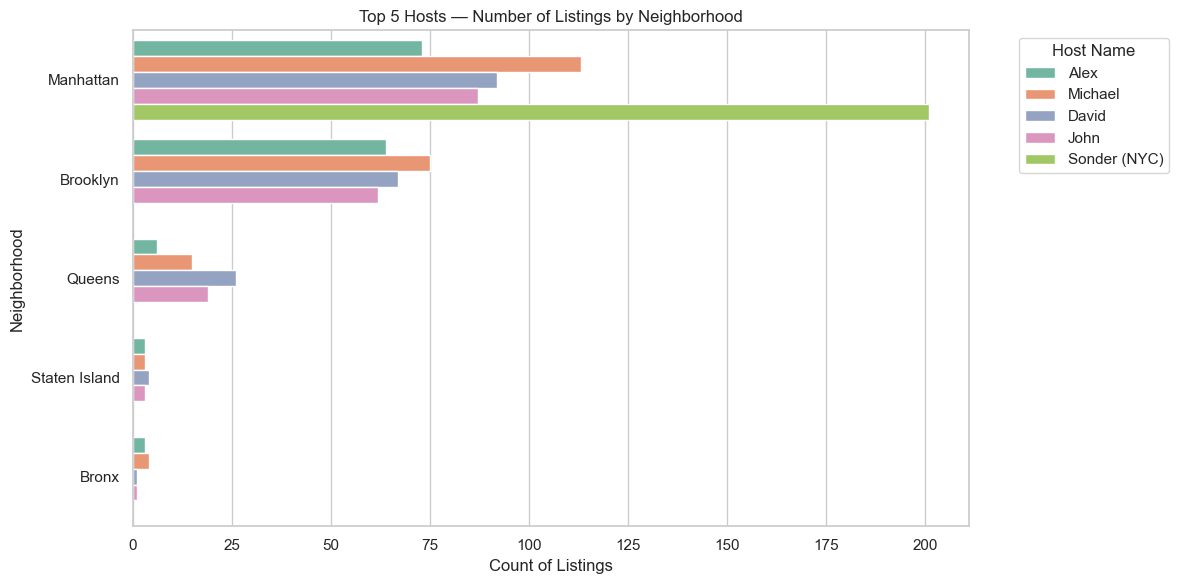

In [169]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=top_host_data,
    y='borough',
    hue='host_name',
    order=top_host_data['borough'].value_counts().index,
    palette='Set2'
)
plt.title('Top 5 Hosts — Number of Listings by Neighborhood')
plt.xlabel('Count of Listings')
plt.ylabel('Neighborhood')
plt.legend(title='Host Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

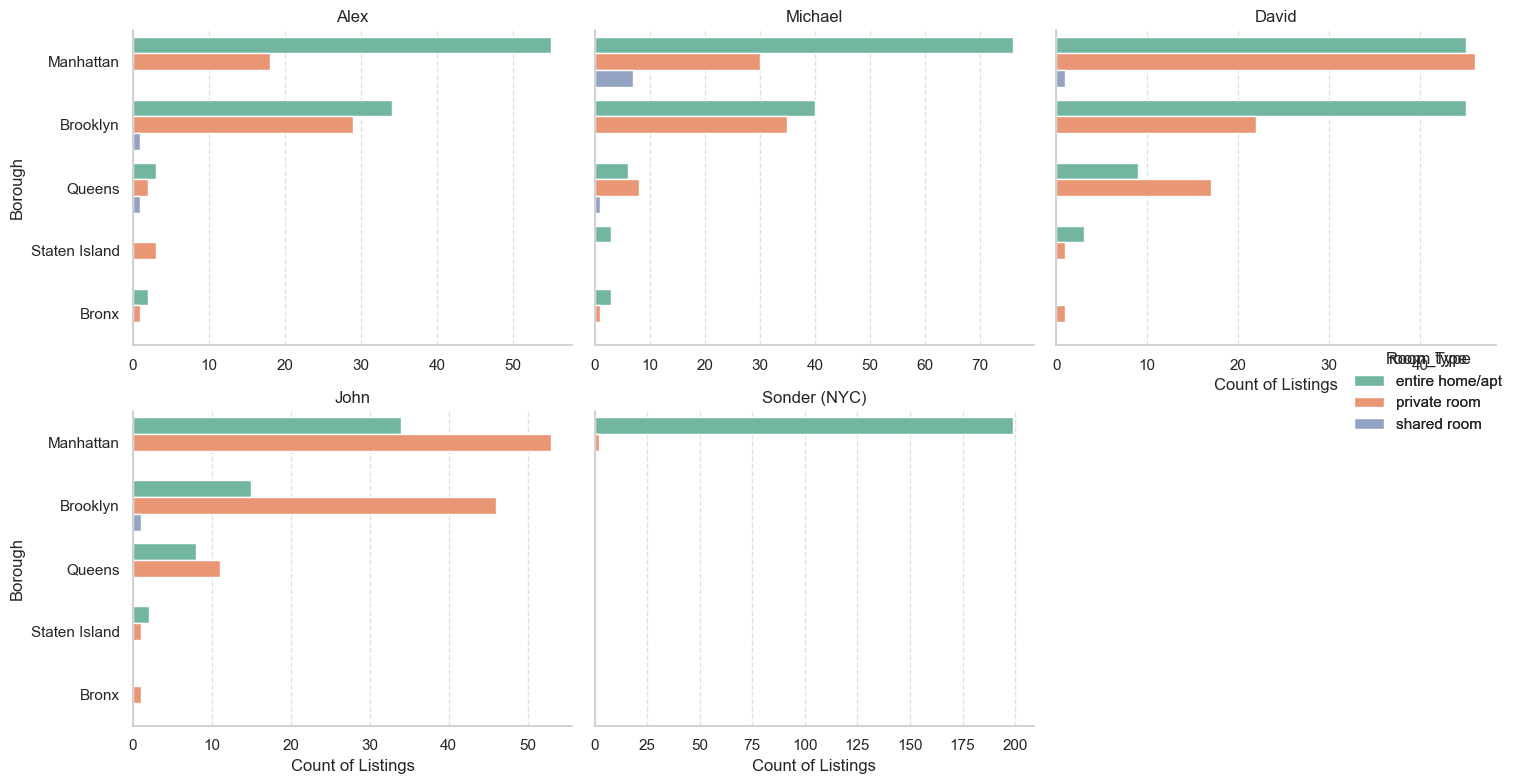

In [170]:
# Order boroughs by how often they appear in top_host_data
borough_order = top_host_data['borough'].value_counts().index

g = sns.catplot(
    data=top_host_data,
    kind='count',
    y='borough',
    hue='room_type',           # color by room type
    col='host_name',           # one panel per host
    col_wrap=3,                # wrap panels (adjust to taste)
    order=borough_order,
    height=4,
    sharex=False,
    palette='Set2'
)

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Count of Listings', 'Borough')
g.add_legend(title='Room Type')

# optional: nicer grid
for ax in g.axes.flatten():
    ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Host Portfolio Analysis — Where and What the Top Hosts Rent

We examined the top 5 hosts by total listing value and broke their portfolios down by **borough** and **room type**.

### 1) Market Concentration by Borough
- The first chart (total listings by host × borough) shows a **strong concentration in Manhattan**, especially for **Sonder (NYC)**, which has far more listings there than any other host.
- **Brooklyn** is the second most active borough across hosts, while **Queens**, **Bronx**, and **Staten Island** account for a much smaller share.

**Interpretation:**  
High-volume hosts prioritize **central, high-demand areas**; Manhattan is the core profit center, with Brooklyn a major secondary market.

---

### 2) Portfolio Mix by Room Type (faceted charts)
Breaking counts down by **room type** within each host:

- **Sonder (NYC)** operates **almost exclusively entire homes/apartments** in **Manhattan**.  
  This is a classic **professional operator** pattern: high nightly rates, consistent product, premium location.
- **Michael, David, and John** have **mixed portfolios**, but **private rooms** make up a **large share** of their listings, especially in **Brooklyn** and **Manhattan**.  
  This aligns with mid-price, high-turnover strategies targeting solo travelers and small groups.
- **Alex** shows a **balanced Manhattan/Brooklyn presence**, with **entire homes** in Manhattan and **more private rooms** in Brooklyn.
- **Shared rooms** are **rare** across all top hosts and boroughs, reflecting low demand for low-privacy options in NYC.

**Interpretation:**  
- **Room type acts as a positioning lever.** Professional/portfolio hosts (e.g., Sonder) skew to **entire homes** in premium areas, while individual hosts rely more on **private rooms** and diversify across boroughs.  
- This creates **clear segmentation**:  
  - *Premium stays* → Entire homes in **Manhattan**  
  - *Value/mid-tier stays* → Private rooms in **Brooklyn/Queens**